Welcome to Data Driven Astronomy online course organised by Positron Foundation

# **Python Refresher and Introduction to Astronomical data**

In this notebook we'll be checking your basic python basics through few simple problems.

Packages we'll be checking :

Numpy<br>
Pandas <br>
Matplotlib



# **Initialization**

Run all the cells below

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# To improve Aesthetics of plots

import matplotlib
matplotlib.rcParams['figure.figsize'] = (15,8)
matplotlib.rcParams['font.size'] = 15

import seaborn as sb
sb.set_style('darkgrid')

In [2]:
# Do not change 
!git clone https://github.com/Jack3690/DDA  

Cloning into 'DDA'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 73 (delta 25), reused 45 (delta 8), pack-reused 0
Unpacking objects: 100% (73/73), done.


In [3]:
cd DDA/Week_1/data 

/content/DDA/Week_1/data


# **Numpy**

Documentation : https://numpy.org/doc/stable/reference/index.html 

## **Problem I**
Write a function which performs operation shown below <br>
 $\hspace{5pt}$  Input $\hspace{25pt}$ Output \\
$\begin{bmatrix}
1 & 2 \\
4 & 3 
\end{bmatrix}
\rightarrow
\begin{bmatrix}
4 & 1 \\
3 & 2 
\end{bmatrix}$

In [4]:
A=np.array([[1,2],
             [4,3]])
# Write a function which takes above array as input and performs a clock-wise rotation of elements
# Hint : Rotational matrices
def rot(A):
  r=np.array([[0,1],
             [1,0]])
  return (r@A).T      # Transpose of r dot A. Here @ is matrix multiplication operator
print("Input\n",A,"\n\nOutput \n",rot(A))

Input
 [[1 2]
 [4 3]] 

Output 
 [[4 1]
 [3 2]]


## **Problem II**

Repeat problem I for an nxn matrix. Also let user decide whether to rotate clockwise or anti clockwise

In [5]:
# Matrix shape input from
n=int(input("Enter Matrix shape : "))
print(f"Matix shape : {n} x {n}")

ch=(input("Clock wise or anti clockwise (A/C) : "))

# nxn matrix Generator
A=np.arange(0,1000,1000/(n**2)).reshape(n,n)
print(f"\n{n} x {n} Matrix :\n\n",A)

# Write a function which takes array and direction of rotion as input and returns array with elements rotated accordingly
# Hint : Find a general formula for making nxn rotational matrix 

def rotn(A,ch):
  n=A.shape[0]
  r=np.zeros((n,n))
  for i in range(n):
    r[i,n-i-1]=1
  print("\nRotational Matrix :\n\n",r)

  if ch=='C' or ch=='c':
    return (r@A).T
  elif ch=='A' or ch=='a':
    return (A@r).T
  else :
    return "Choose A or C "

# Just for cosmetic purpose
dir={ 'A': "Anti-Clockwise",
      'C' : "Clockwise"}
print(f"\nMatrix after rotating along {dir[ch.upper()]} direction :\n\n",rotn(A,ch))

Enter Matrix shape : 3
Matix shape : 3 x 3
Clock wise or anti clockwise (A/C) : c

3 x 3 Matrix :

 [[  0.         111.11111111 222.22222222]
 [333.33333333 444.44444444 555.55555556]
 [666.66666667 777.77777778 888.88888889]]

Rotational Matrix :

 [[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]

Matrix after rotating along Clockwise direction :

 [[666.66666667 333.33333333   0.        ]
 [777.77777778 444.44444444 111.11111111]
 [888.88888889 555.55555556 222.22222222]]


## **Bonus Problem : 3x3 Rubik's Cube**
Define a function which can rotate any chosen slice of a 3 x 3 x 3 matrix

 ![alt text](https://media.geeksforgeeks.org/wp-content/uploads/3D-array.jpg)

In [7]:
"""
Hint

Slices   
Top Bottom
Left Right
Front Back

"""
slice_=input("Enter side : ")

Enter side : a


# **Pandas**
Documentation :https://pandas.pydata.org/pandas-docs/stable/reference/index.html

About Data : https://arxiv.org/abs/1406.4179

In [8]:
df=pd.read_csv('meert.csv')
df

,ra,dec,z,veldisp,veldispErr,eclass,p_el_debiased,p_cs_debiased,spiral,elliptical,uncertain
0,236.247,-0.475264,0.030284,-9999.000,-9999.0000,0.159350,0.165,0.739,0,0,1
1,236.287,-0.518003,0.077923,-9999.000,-9999.0000,0.054718,0.029,0.937,1,0,0
2,236.342,-0.467023,0.160228,-9999.000,-9999.0000,-0.120854,0.211,0.763,0,0,1
3,236.350,-0.598237,0.071558,-9999.000,-9999.0000,-0.043624,0.171,0.787,1,0,0
4,236.369,-0.574450,0.071975,-9999.000,-9999.0000,-0.068106,0.019,0.981,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
670717,217.363,1.049700,0.086556,131.273,10.7453,-0.163945,1.000,0.000,0,1,0
670718,226.463,1.074650,0.087805,-9999.000,-9999.0000,0.027229,-888.000,-888.000,-888,-888,-888
670719,226.547,1.114430,0.104590,-9999.000,-9999.0000,-0.131829,-888.000,-888.000,-888,-888,-888
670720,226.596,1.148130,0.126815,-9999.000,-9999.0000,0.048498,-888.000,-888.000,-888,-888,-888


## **Problem I (a)**
Find the minimum, maxium and mean redshift(z) of data

In [9]:
df['z'].describe()

count    670722.000000
mean          0.107776
std           0.053485
min           0.005007
25%           0.068795
50%           0.101573
75%           0.140906
max           0.843643
Name: z, dtype: float64

## **Problem I (b)**

Count the number of spiral and elliptical galaxies

In [10]:
print(f"Spirals    : {len(df[df['spiral']==1])}\nElliptical : {len(df[df['elliptical']==1])}")

Spirals    : 187005
Elliptical : 60561


## **Problem I (c)**

Show data of uncertain galaxies with p_cs_debiased greater or equal to 0.5 and is 



In [ ]:
df[(df['p_cs_debiased']>=0.5) & (df['uncertain'] ==1)]

,ra,dec,z,veldisp,veldispErr,eclass,p_el_debiased,p_cs_debiased,spiral,elliptical,uncertain
0,236.247,-0.475264,0.030284,-9999.0000,-9999.0000,0.159350,0.165,0.739,0,0,1
2,236.342,-0.467023,0.160228,-9999.0000,-9999.0000,-0.120854,0.211,0.763,0,0,1
15,237.350,-0.602748,0.077890,-9999.0000,-9999.0000,-0.005628,0.113,0.837,0,0,1
17,237.454,-0.423187,0.095409,-9999.0000,-9999.0000,-0.145045,0.107,0.627,0,0,1
18,237.525,-0.590604,0.113105,-9999.0000,-9999.0000,0.092446,0.137,0.554,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
670701,211.298,1.087240,0.167299,-9999.0000,-9999.0000,-0.084719,0.197,0.649,0,0,1
670703,211.816,1.065030,0.034688,-9999.0000,-9999.0000,0.328660,0.242,0.574,0,0,1
670705,212.976,1.070010,0.146986,-9999.0000,-9999.0000,0.014341,0.141,0.668,0,0,1
670706,212.996,1.102980,0.094524,98.9081,21.7494,-0.037958,0.297,0.501,0,0,1


## **Problem II**

Find the  ra and dec of source with highest redshift(z) for <br>
a) Spiral galaxy <br>
b) Elliptical Galaxy


In [ ]:
# Hint : Make new separate dataframes for Spiral and ellpitical

df_t= df[ (df['spiral']==1) ]
print("Spiral Galaxy with highest Redshift")
df_t[df_t['z']==df_t['z'].max()][['ra','dec']]

Spiral Galaxy with highest Redshift


,ra,dec
535845,159.472,3.99856


In [ ]:
df_t= df[ (df['elliptical']==1) ]
print("Elliptical Galaxy with highest Redshift")
df_t[df_t['z']==df_t['z'].max()][['ra','dec']]

Elliptical Galaxy with highest Redshift


,ra,dec
148692,27.2117,-0.112192


## **Problem III**

Sort the table in increasing order of redshift and show ra, dec and z of top 10 sources

In [ ]:
df.sort_values('z')[['ra','dec','z']].head(10)

,ra,dec,z
84944,172.375,3.228700,0.005007
651515,161.946,46.879300,0.005008
356671,142.901,27.296300,0.005009
158369,163.553,54.287200,0.005016
351847,162.332,32.730600,0.005022
363074,205.348,33.858200,0.005023
19392,146.008,-0.642271,0.005024
509609,186.469,5.809650,0.005026
597928,170.711,12.344900,0.005030
531640,186.279,61.657500,0.005032


# **Matplotlib**

Documentation : https://matplotlib.org/3.1.1/api/index.html

## **Problem I**

Plot redshifts of spiral and elliptical galaxies on a single plot which follows the condition below

1) Plot should be in increasing order of redshift

2) Spiral should be plotted with red line 

3) Elliptical should be plooted with blue line 

4) Show legend, x label, y label and title

In [ ]:
df_s = df[df['spiral']==1].sort_values('z')
df_s

,ra,dec,z,veldisp,veldispErr,eclass,p_el_debiased,p_cs_debiased,spiral,elliptical,uncertain
502088,165.462,16.606900,0.010016,-9999.0,-9999.0,0.076773,0.000,1.000,1,0,0
547129,210.787,59.433400,0.010038,-9999.0,-9999.0,0.104913,0.000,1.000,1,0,0
604523,176.510,41.884000,0.010044,-9999.0,-9999.0,0.211843,0.069,0.873,1,0,0
309979,147.199,64.166900,0.010046,-9999.0,-9999.0,0.050031,0.107,0.893,1,0,0
117603,234.870,0.943408,0.010066,-9999.0,-9999.0,0.155318,0.026,0.830,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
47704,201.147,1.574900,0.808146,-9999.0,-9999.0,0.000000,0.031,0.812,1,0,0
544942,165.167,61.320600,0.819552,-9999.0,-9999.0,0.000000,0.000,1.000,1,0,0
329870,149.921,31.684700,0.820786,-9999.0,-9999.0,0.000000,0.031,0.969,1,0,0
202849,197.151,53.289300,0.821760,-9999.0,-9999.0,0.000000,0.139,0.833,1,0,0


In [ ]:
df_e = df[df['elliptical']==1].sort_values('z')
df_e

,ra,dec,z,veldisp,veldispErr,eclass,p_el_debiased,p_cs_debiased,spiral,elliptical,uncertain
653265,173.4270,50.449600,0.010055,-9999.0000,-9999.00000,0.383389,0.830,0.050,0,1,0
506730,174.9760,17.882000,0.010369,37.2847,14.88800,-0.050813,0.845,0.126,0,1,0
301616,214.8090,36.359400,0.010522,39.3561,7.89711,-0.072628,0.875,0.065,0,1,0
300766,210.5250,36.611200,0.010523,-9999.0000,-9999.00000,0.136684,0.881,0.087,0,1,0
247472,176.6640,14.560400,0.010604,-9999.0000,-9999.00000,0.205464,0.766,0.133,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
105941,231.9790,59.467400,0.369229,331.9380,42.85160,-0.160680,0.828,0.103,0,1,0
50005,148.2390,2.005410,0.373864,342.5530,47.25320,-0.107303,0.877,0.053,0,1,0
351729,167.3300,33.244700,0.375842,414.2750,37.02580,-0.136051,0.838,0.000,0,1,0
150354,50.1178,0.736039,0.388304,-9999.0000,-9999.00000,-0.171157,0.818,0.030,0,1,0


Text(0.5, 1.0, 'Redshift distribution')

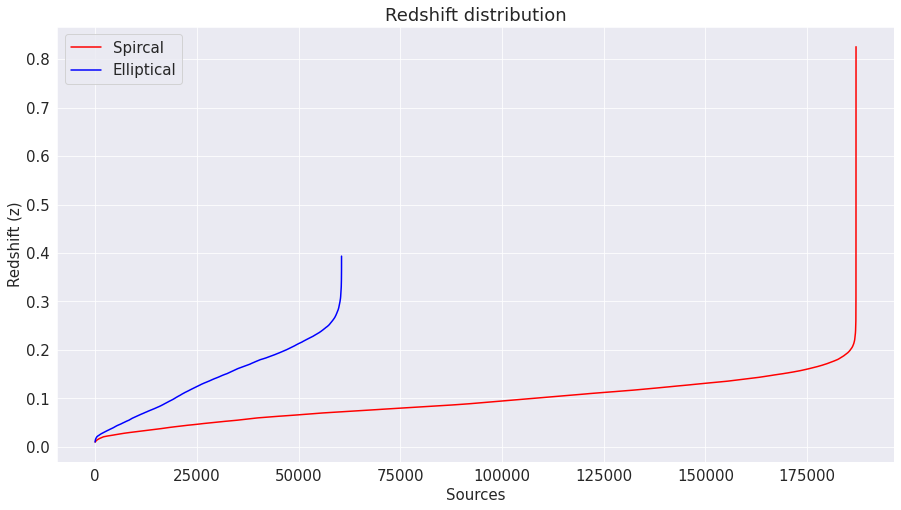

In [ ]:
z_s = df_s['z'].values
z_e = df_e['z'].values

plt.plot(z_s,color='red')

plt.plot(z_e,color='blue')

plt.legend(['Spircal','Elliptical'])
plt.xlabel('Sources')
plt.ylabel('Redshift (z)')
plt.title("Redshift distribution")

## **Problem II**

Plot histogram for redshift of spiral and elliptical galaxies in same plot which follows the conditions below :

1) Use np.arange for bins

2) Bins ( min, max and width ) should be same for both histograms. ( use width = 0.01)

3) Use log scale in y axis

4) Show legend, axes and title


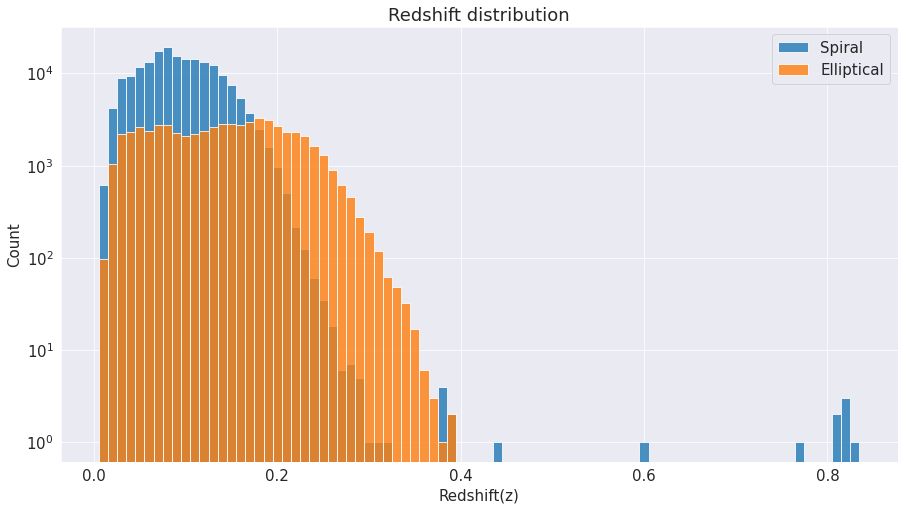

In [ ]:
plt.hist(z_s, bins=np.arange(df['z'].min(), df['z'].max(),0.01), alpha=0.8)
plt.hist(z_e, bins=np.arange(df['z'].min(), df['z'].max(),0.01), alpha=0.8)
plt.xlabel("Redshift(z)")
plt.ylabel('Count')
plt.title('Redshift distribution')
plt.legend(['Spiral','Elliptical'])
plt.yscale('log')

## **Problem III**

Make scatter plot of ra and dec of source using following conditions :

1) Choose souces with Top 100 redshifts( Top in descending order)

2) Ra in x, Dec in y and redshift in c

2) Spirals using circle

3) Ellipticals using square

4) Use cmap='viridis'

4) Show legend, axes, colorbar and title

Text(0.5, 1.0, 'High Redshift sources in the sky')

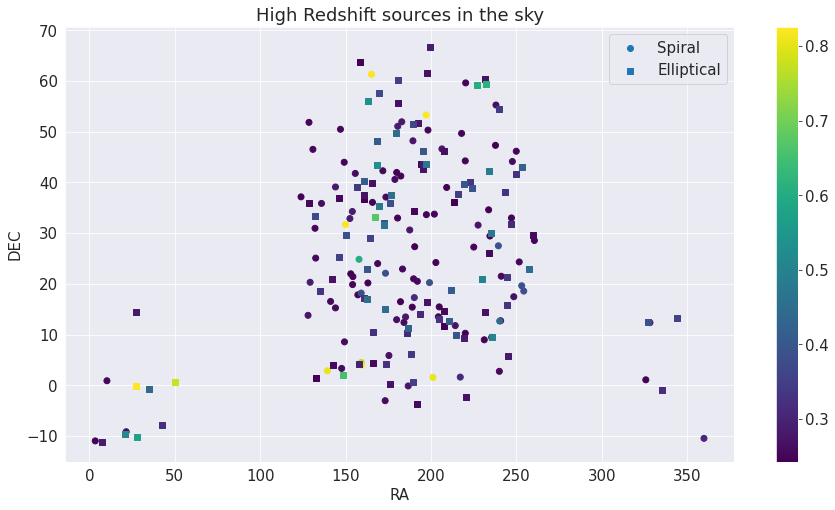

In [ ]:
x=df_s[-100:]['ra'].values
y=df_s[-100:]['dec'].values
z=df_s[-100:]['z'].values

plt.scatter(x,y,c=z,marker='o',cmap='viridis')

plt.colorbar()
x=df_e[-100:]['ra'].values
y=df_e[-100:]['dec'].values
z=df_e[-100:]['z'].values

plt.scatter(x,y,c=z,marker='s',cmap='viridis');


plt.xlabel('RA')
plt.ylabel('DEC')

plt.legend(['Spiral','Elliptical'])
plt.title('High Redshift sources in the sky')